In [1]:
#Norms
import numpy as np

x=np.array([4,-3,7,1])
l1=np.linalg.norm(x,1)
l2=np.linalg.norm(x,2)
l3=np.linalg.norm(x,np.inf)

print("L1: ",l1)
print("L2: ",l2)
print("L3: ",l3)


L1:  15.0
L2:  8.660254037844387
L3:  7.0


In [4]:
#norms inlasso reg model
#to prexict student performance in clg
import pandas as pd 
import numpy as np  # Added numpy import for np.abs and np.max
from sklearn.linear_model import Lasso
from sklearn.metrics.pairwise import euclidean_distances  # Fixed function name

#createdata set
data={
    "Hours_Studied":[2,4,6,8,10],
    "Attendance":[50,60,70,80,90],
    "Sleep_Hours":[6,7,5,6,7],
    "Shoe_Size":[6,7,8,9,10],
    "Score":[40,50,65,80,90]
}
df=pd.DataFrame(data)
x=df.drop("Score",axis=1)  # Fixed column name from "score: " to "Score"
y=df["Score"]
print(" dataset: \n",df)

#L norm features selection
lasso=Lasso(alpha=0.1)
lasso.fit(x,y)
print("\n lasso coefficients: ")
for feature, coef in zip(x.columns,lasso.coef_):
    print(f"{feature}: {coef:.4f}")

#L2 norm -student similarity
stud1=x.iloc[0].values.reshape(1,-1)
stud2=x.iloc[4].values.reshape(1,-1)

distance=euclidean_distances(stud1,stud2)  # Fixed function name from euclidean_distance to euclidean_distances
print("\n L2 distance between stud1 and stud 5: ",distance[0][0])

#L infinity norm-> max error checks
predictions=lasso.predict(x)  # Changed from y to x as we predict using features, not target
errors=np.abs(predictions-y)
linf_error=np.max(errors)
print("\n Predictions: ",predictions)
print("Actual: ",list(y))
print(" errors: ",errors)
print("L infinity norm (max error): ",linf_error)

 dataset: 
    Hours_Studied  Attendance  Sleep_Hours  Shoe_Size  Score
0              2          50            6          6     40
1              4          60            7          7     50
2              6          70            5          8     65
3              8          80            6          9     80
4             10          90            7         10     90

 lasso coefficients: 
Hours_Studied: 0.0000
Attendance: 1.3087
Sleep_Hours: -0.9241
Shoe_Size: 0.0000

 L2 distance between stud1 and stud 5:  41.0

 Predictions:  [39.01       51.17333333 66.10888889 78.27222222 90.43555556]
Actual:  [40, 50, 65, 80, 90]
 errors:  0    0.990000
1    1.173333
2    1.108889
3    1.727778
4    0.435556
Name: Score, dtype: float64
L infinity norm (max error):  1.7277777777777459


 dot prod is :  0
 vectors are orthogonal(perpendicular)


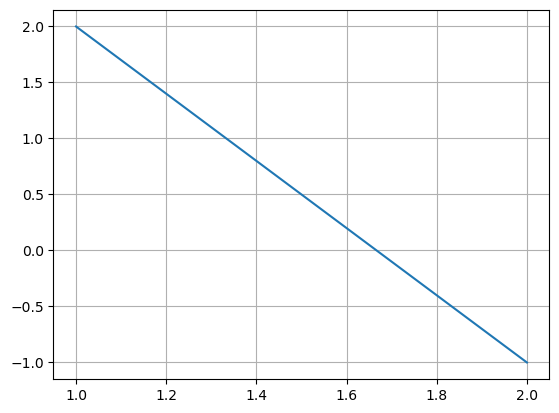

In [7]:
import numpy as np
import matplotlib.pyplot as plt
a=np.array([1,2])
b=np.array([2,-1])
dot_prod=np.dot(a,b)
print(" dot prod is : ",dot_prod)
if dot_prod==0:
    print(" vectors are orthogonal(perpendicular)")
else:
    print("vectors are not orthogonal")
plt.plot(a,b)
plt.grid()
plt.show()

 Original dataset: 
    income  color
0   25000    red
1   50000   blue
2   75000  green
3   30000   blue
4   90000    red

 Encoded dataset: 
    income  color_blue  color_green  color_red
0   25000         0.0          0.0        1.0
1   50000         1.0          0.0        0.0
2   75000         0.0          1.0        0.0
3   30000         1.0          0.0        0.0
4   90000         0.0          0.0        1.0

 dot product (income vs red):  115000.0
correlation btw income and  red:  0.11349527614696626


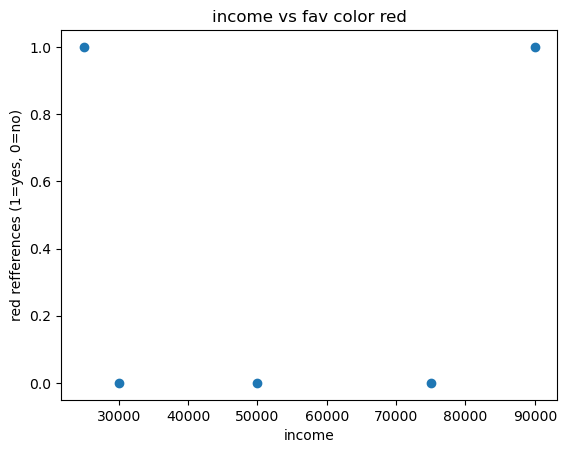

In [12]:
#checking relationship between employee income and favourite colour
from sklearn.preprocessing import OneHotEncoder
#create dataset
data={
    "income":[25000,50000,75000,30000,90000],
    "color":["red","blue","green","blue","red"]
}
df=pd.DataFrame(data)
print(" Original dataset: \n",df)
#one hot encoding
encoder=OneHotEncoder(sparse_output=False)  #o/p as normal arrayt not a sparse matrix
color_encoded=encoder.fit_transform(df[["color"]])
color_df=pd.DataFrame(color_encoded,columns=encoder.get_feature_names_out())  #convert encoded val into labeled tabel
#combine income with encode color
x=pd.concat([df["income"],color_df],axis=1)
print("\n Encoded dataset: \n",x)
#data product
income_vector=x["income"].values
red_vector=x["color_red"].values
dot_product=np.dot(income_vector,red_vector)
print("\n dot product (income vs red): ",dot_product)
#correlation
correlation=np.corrcoef(income_vector,red_vector)[0,1]
print("correlation btw income and  red: ",correlation)
#visualition
plt.figure()
plt.scatter(income_vector,red_vector)
plt.xlabel("income")
plt.ylabel("red refferences (1=yes, 0=no)")
plt.title("income vs fav color red")
plt.show()

 query digit:  0

 top similar indices:  [ 10 334 812 256 160 848]
similarity scores:  [1.         0.96493807 0.95939227 0.95478125 0.95323395 0.95290124]


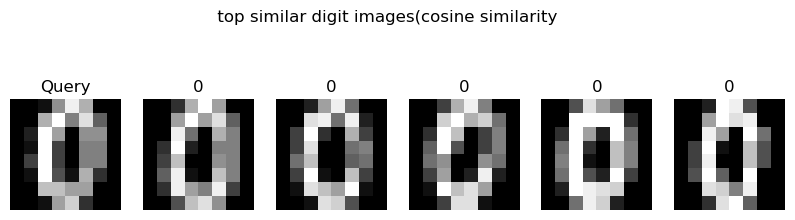

In [20]:
from sklearn.datasets import load_digits
from sklearn.metrics.pairwise import cosine_similarity
#load dataset
digits=load_digits()
x=digits.data  #shape(1797,64)
y=digits.target
# select querry image
query_index=10
query_image=x[query_index]
print(" query digit: ",y[query_index])
#compute cosine similarity
similarities=cosine_similarity([query_image],x)[0]
#get top 5 similar image
top_indices=np.argsort(similarities)[-6:][::-1]  #top 6 including itself
print("\n top similar indices: ",top_indices)
print("similarity scores: ",similarities[top_indices])
#visualisation
plt.figure(figsize=(10,3))
#show query image
plt.subplot(1,6,1)
plt.imshow(query_image.reshape(8,8),cmap='gray')
plt.title("Query")
plt.axis('off')
#show top matches
for i,idx in enumerate(top_indices[1:]): #skip itself
    plt.subplot(1,6,i+2)
    plt.imshow(x[idx].reshape(8,8),cmap='gray')
    plt.title(f"{y[idx]}")
    plt.axis('off')
plt.suptitle(" top similar digit images(cosine similarity")
plt.show()